# News Sentiment and S&P 500 Market Movement Analysis

This notebook uses RavenPack market-related news headlines to create financial news sentiment scores and connect them to daily S&P 500 returns.

The main question is to know how are the tone and volume of market-related news associated with S&P 500 movements.

### Group 12: Annie Chen, Claire Kim

## Introduction

This analysis is designed for retail investors and quantitative analysts who are interested in understanding whether financial news sentiment can be used to inform trading decisions or market timing. In practice, many investors rely on news and media tone to form expectations about market movements, but it is not always clear whether this information provides any real predictive value.

The main goal of this project is to evaluate whether the sentiment of financial news headlines is meaningfully related to S&P 500 returns, either on the same day or the following trading day. If such a relationship exists, sentiment could potentially serve as a useful signal for investment decisions. If not, it suggests that relying on news tone alone may not be effective.

To address this question, we construct sentiment measures from news headlines using a combination of the Loughran-McDonald (LM) financial dictionary and the VADER sentiment model. These sentiment scores are aggregated to the daily level and aligned with S&P 500 market data.

We then perform exploratory analysis to examine patterns in sentiment, market returns, and their relationship. This includes distributional analysis, time-series visualization, and comparisons across different sentiment and news volume conditions. The purpose of this analysis is to assess whether sentiment provides meaningful insight for the target audience or whether its usefulness is limited in practice.

## 1. Load and Inspect News Data

We first load the news dataset and inspect its data types, missing values, and overall shape. We do this data quality check even when the dataset comes from a reliable source, because the loaded data may still contain missing values, unexpected formats, or variables that require cleaning before analysis.

In [1]:
# Import pandas for data loading, cleaning, and manipulation.
import pandas as pd

# Load the RavenPack news sentiment dataset from the local CSV file.
news_sentiment = pd.read_csv("news_sentiment.csv")

In [2]:
# pd.set_option('display.max_colwidth', None)
news_sentiment.head()

,rpa_date_utc,event_sentiment_score,topic,headline
0,2016-05-02,NaN,NaN,MW Japanese stocks tumble as yen surges
1,2016-05-02,NaN,NaN,Allianz Reports Robust Results
2,2016-05-02,NaN,NaN,"Modern Land (China) Forms AMG Capital, LLC to ..."
3,2016-05-02,NaN,NaN,Halliburton and Baker Hughes Announce Terminat...
4,2016-05-02,NaN,NaN,Buffett Downplays Impact of Election


In [3]:
# Check column names, data types, and non-null counts.
news_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9372407 entries, 0 to 9372406
Data columns (total 4 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   rpa_date_utc           object 
 1   event_sentiment_score  float64
 2   topic                  object 
 3   headline               object 
dtypes: float64(1), object(3)
memory usage: 286.0+ MB


In [4]:
# Count missing values in each column.
news_sentiment.isnull().sum()

rpa_date_utc                   0
event_sentiment_score    8665899
topic                    8665899
headline                       0
dtype: int64

In [5]:
# Check the size of the dataset before any filtering or transformations.
news_sentiment.shape

(9372407, 4)

A large portion of the dataset contains observations without sentiment scores, indicating that not all news entries are classified as structured events. 

To ensure meaningful analysis, we restrict the dataset to observations with valid sentiment scores. Additionally, we apply a relevance filter to remove low-importance mentions that are unlikely to impact financial markets.

This step helps reduce noise and ensures that our analysis focuses on economically meaningful news events.

## 2. Sentiment Analysis Using LM Dictionary and VADER

We create headline-level sentiment scores using two methods:

1. Loughran-McDonald (LM) Dictionary: a finance-specific sentiment dictionary.
2. VADER: a general-purpose sentiment tool that works well for short text.

We combine these two measures to create a hybrid sentiment score. When financial keywords are present, we place greater weight on the LM score. Otherwise, we rely on VADER to capture general sentiment.

This hybrid approach allows us to better capture both financial meaning and linguistic tone in news headlines.

In [6]:
# If vaderSentiment is not installed, uncomment and run this line.
# ! pip install vaderSentiment

In [7]:
# Load the Loughran-McDonald financial sentiment dictionary.
# This dictionary identifies finance-specific positive and negative words.
lm_dic = pd.read_csv('Loughran-McDonald_MasterDictionary_1993-2025.csv')

# Build lookup sets for negative and positive financial words.
# We convert words to uppercase so they match the uppercase tokenization used later.
negative_words  = set(lm_dic[lm_dic['Negative']  > 0]['Word'])
positive_words  = set(lm_dic[lm_dic['Positive']  > 0]['Word'])

In [8]:
# Import VADER sentiment analyzer.
# VADER returns a compound score between -1 and +1 for each headline.
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

In [ ]:
# Import regular expressions for cleaner word tokenization.
import re

threshold = 0.05
def analyze_headline(headline):
    # 1. LM Score (-1/0/+1 per word, averaged)
    # re.findall removes punctuation, so words like "LOSS," become "LOSS".
    words = re.findall(r'\b\w+\b', headline.upper())
    lm_scores = []
    for w in words:
        if w in negative_words:   lm_scores.append(-1)
        elif w in positive_words: lm_scores.append(1)
    
    # Average across matched LM words only.
    # If no LM words are found, LM score is set to 0.
    lm_score = sum(lm_scores) / len(lm_scores) if lm_scores else 0

    # 2. VADER score: use lowercase to avoid treating all-caps headlines as artificial emphasis.
    vader_score = vader.polarity_scores(headline.lower())['compound']

    # 3. Combined score: if LM finds finance words, weight LM more heavily.
    # Otherwise, rely fully on VADER.
    if lm_scores:  # LM found relevant finance words
        final_score = (lm_score * 0.6) + (vader_score * 0.4)
    else:          # No finance words found, rely on VADER fully
        final_score = vader_score

    # Convert the numerical score into a simple sentiment label.
    sentiment = (
        "positive" if final_score > threshold else
        "negative" if final_score < -threshold else
        "neutral"
    )

    return {
        "headline":    headline,
        "lm_score":    round(lm_score, 3),
        "vader_score": round(vader_score, 3),
        "final_score": round(final_score, 3),
        "sentiment":   sentiment
    }


In [10]:
# Apply the sentiment function to every headline.
sentiment_results = news_sentiment["headline"].apply(analyze_headline)

In [11]:
# Convert the list of dictionaries into a dataframe.
sentiment_df = pd.DataFrame(sentiment_results.tolist())

# Add sentiment columns to the original dataset.
# Drop the duplicated headline column from sentiment_df because news_sentiment already has headline.
news_sentiment = pd.concat([news_sentiment, sentiment_df.drop(columns="headline")], axis=1)

In [12]:
news_sentiment.head()

,rpa_date_utc,event_sentiment_score,topic,headline,lm_score,vader_score,final_score,sentiment
0,2016-05-02,NaN,NaN,MW Japanese stocks tumble as yen surges,0.0,0.000,0.000,neutral
1,2016-05-02,NaN,NaN,Allianz Reports Robust Results,0.0,0.340,0.340,positive
2,2016-05-02,NaN,NaN,"Modern Land (China) Forms AMG Capital, LLC to ...",0.0,0.178,0.178,positive
3,2016-05-02,NaN,NaN,Halliburton and Baker Hughes Announce Terminat...,-1.0,0.494,-0.402,negative
4,2016-05-02,NaN,NaN,Buffett Downplays Impact of Election,0.0,0.000,0.000,neutral


## 3. Load S&P 500 Data from FRED API

The S&P 500 is used as a broad proxy for U.S. market movement. Instead of using raw prices directly, we calculate daily returns because returns measure market movement more clearly than price levels.

In [13]:
# Import requests to call the FRED API.
import requests

api_key = "3bfc533b8b5b7688bffbe48e56a098b5"

url = "https://api.stlouisfed.org/fred/series/observations"

# Request S&P 500 data from FRED.
params = {
    "series_id": "SP500", 
    "api_key": api_key,
    "file_type": "json",
    "observation_start": "2004-01-01"
}


response = requests.get(url, params=params)

data = response.json()

# Convert API response into a dataframe.
sp500 = pd.DataFrame(data["observations"])

# Parse dates and convert price values to numeric.
sp500["date"] = pd.to_datetime(sp500["date"])
sp500["price"] = pd.to_numeric(sp500["value"], errors="coerce")

# Keep only the columns needed for analysis.
sp500 = sp500[["date", "price"]]

sp500.head()

,date,price
0,2016-05-02,2081.43
1,2016-05-03,2063.37
2,2016-05-04,2051.12
3,2016-05-05,2050.63
4,2016-05-06,2057.14


In [14]:
# Calculate daily S&P 500 returns.
# pct_change() gives decimal returns, so -0.0087 means approximately -0.87%.
sp500["daily_return"] = sp500["price"].pct_change()

/var/folders/jb/_57y0k0x0wj5rxjpxc000yxc0000gn/T/ipykernel_33177/1091009651.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sp500["daily_return"] = sp500["price"].pct_change()


In [15]:
# Create lag-day return.
sp500["lag_return"] = sp500["daily_return"].shift(-1)

In [16]:
sp500.head()

,date,price,daily_return,lag_return
0,2016-05-02,2081.43,NaN,-0.008677
1,2016-05-03,2063.37,-0.008677,-0.005937
2,2016-05-04,2051.12,-0.005937,-0.000239
3,2016-05-05,2050.63,-0.000239,0.003175
4,2016-05-06,2057.14,0.003175,0.000753


## 4. Prepare News Dates

RavenPack has both "rpa_date_utc" and "timestamp_utc". Here we use the news date as the original news date. This will later be aligned to the next available S&P 500 trading day.

In [17]:
# Change column name for news data from "rpa_date_utc" to "date" and the "date" to datetime so it can be merged with S&P 500 dates.
news_sentiment["date"] = pd.to_datetime(news_sentiment["rpa_date_utc"])

# Drop the original date column after creating a standardized date column.
news_sentiment = news_sentiment.drop(columns="rpa_date_utc")
news_sentiment.head()

,event_sentiment_score,topic,headline,lm_score,vader_score,final_score,sentiment,date
0,NaN,NaN,MW Japanese stocks tumble as yen surges,0.0,0.000,0.000,neutral,2016-05-02
1,NaN,NaN,Allianz Reports Robust Results,0.0,0.340,0.340,positive,2016-05-02
2,NaN,NaN,"Modern Land (China) Forms AMG Capital, LLC to ...",0.0,0.178,0.178,positive,2016-05-02
3,NaN,NaN,Halliburton and Baker Hughes Announce Terminat...,-1.0,0.494,-0.402,negative,2016-05-02
4,NaN,NaN,Buffett Downplays Impact of Election,0.0,0.000,0.000,neutral,2016-05-02


## 5. Align News Dates with Trading Dates

News can be released on weekends or holidays, while the S&P 500 only has observations on trading days. We use 'merge_asof(..., direction="forward")' to map each news item to the next available trading day.

In [18]:
# Keep the original news date separately from the matched trading date.
news_sentiment["original_date"] = news_sentiment["date"]
sp500["trading_date"] = sp500["date"]

In [19]:
# Keep only the S&P 500 columns needed for the merge.
sp500_for_merge = sp500[["trading_date", "price", "daily_return", "lag_return"]].copy()

In [20]:
# merge_asof requires both dataframes to be sorted by the merge keys.
news_sentiment = news_sentiment.sort_values("original_date")
sp500_for_merge = sp500_for_merge.sort_values("trading_date")

In [21]:
# Align each news headline with the next available S&P 500 trading day.
news_sp500 = pd.merge_asof(
    news_sentiment,
    sp500_for_merge,
    left_on="original_date",
    right_on="trading_date",
    direction="forward"
)

In [22]:
# Check if there are rows where the original news date is different from the trading date.
# These are usually weekend or non-trading-day observations.
(news_sp500[news_sp500["trading_date"] != news_sp500["original_date"]]).head()

,event_sentiment_score,topic,headline,lm_score,vader_score,final_score,sentiment,date,original_date,trading_date,price,daily_return,lag_return
20916,NaN,NaN,Evonik to Acquire Air Products Unit -- WSJ,0.0,0.000,0.000,neutral,2016-05-07,2016-05-07,2016-05-09,2058.69,0.000753,0.012484
20917,NaN,NaN,Toyota Has Big Plans for Tiniest Cars -- WSJ,0.0,0.000,0.000,neutral,2016-05-07,2016-05-07,2016-05-09,2058.69,0.000753,0.012484
20918,NaN,NaN,Toshiba Names CEO To Continue Overhaul -- WSJ,0.0,0.000,0.000,neutral,2016-05-07,2016-05-07,2016-05-09,2058.69,0.000753,0.012484
20919,NaN,NaN,Charter Purchase Of TWC Cleared -- WSJ,0.0,0.103,0.103,positive,2016-05-07,2016-05-07,2016-05-09,2058.69,0.000753,0.012484
20920,NaN,NaN,Commodities Report: Rio Tinto to Expand Copper...,0.0,0.318,0.318,positive,2016-05-07,2016-05-07,2016-05-09,2058.69,0.000753,0.012484


In [23]:
# Calculate how many calendar days each news item was shifted forward.
# lag_days = 0 means same-day trading date; lag_days > 0 means the news was mapped to a later trading day.
news_sp500["lag_days"] = (
    news_sp500["trading_date"] - news_sp500["original_date"]
).dt.days

news_sp500["lag_days"].value_counts().sort_index()

lag_days
0    9059632
1      97335
2     215440
Name: count, dtype: int64

## 6. Aggregate News to Daily Trading-Date Level

The raw news dataset is headline-level, while S&P 500 returns are daily. Therefore, we aggregate news by "trading_date" so that each row represents one trading day.

In [24]:
# Create daily news sentiment features.
# news_count captures news volume, while avg_sentiment captures the average sentiment tone for the day.
daily_news = (
    news_sp500
    .groupby("trading_date")
    .agg(
        news_count=("headline", "count"),
        avg_sentiment=("final_score", "mean"),
        median_sentiment=("final_score", "median"),
        avg_lm_score=("lm_score", "mean"),
        avg_vader_score=("vader_score", "mean")
    )
    .reset_index()
)

In [25]:
# Count how many positive, negative, and neutral headlines occur on each trading date.
sentiment_counts = (
    news_sp500
    .groupby(["trading_date", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Merge daily sentiment counts into the daily_news dataframe.
daily_news = daily_news.merge(sentiment_counts, on="trading_date", how="left")

In [26]:
# Convert sentiment counts into shares.
daily_news["positive_share"] = daily_news.get("positive", 0) / daily_news["news_count"]
daily_news["negative_share"] = daily_news.get("negative", 0) / daily_news["news_count"]
daily_news["neutral_share"] = daily_news.get("neutral", 0) / daily_news["news_count"]

## 7. Merge Daily News Features with S&P 500 Returns

Finally, we merge the daily news sentiment dataset with S&P 500 returns. This creates the main analysis dataset for examining the relationship between news sentiment and market movement.

In [27]:
sp500["trading_date"] = pd.to_datetime(sp500["date"])

# Merge daily news features with S&P 500 returns by trading date.
daily_merged = daily_news.merge(
    sp500[["trading_date", "price", "daily_return", "lag_return"]],
    on="trading_date",
    how="inner"
)

In [28]:
daily_merged.head()

,trading_date,news_count,avg_sentiment,median_sentiment,avg_lm_score,avg_vader_score,negative,neutral,positive,positive_share,negative_share,neutral_share,price,daily_return,lag_return
0,2016-05-02,3312,0.113014,0.0,0.023752,0.124093,426,1752,1134,0.342391,0.128623,0.528986,2081.43,NaN,-0.008677
1,2016-05-03,4879,0.101657,0.0,0.019813,0.108973,623,2552,1704,0.349252,0.127690,0.523058,2063.37,-0.008677,-0.005937
2,2016-05-04,4877,0.085079,0.0,0.002119,0.100860,635,2674,1568,0.321509,0.130203,0.548288,2051.12,-0.005937,-0.000239
3,2016-05-05,4984,0.085063,0.0,0.012139,0.095300,573,2935,1476,0.296148,0.114968,0.588884,2050.63,-0.000239,0.003175
4,2016-05-06,2864,0.054049,0.0,-0.047427,0.091944,564,1323,977,0.341131,0.196927,0.461941,2057.14,0.003175,0.000753


# EDA

In [29]:
# EDA setup
import matplotlib.pyplot as plt
import numpy as np

### Data Quality Checks

In [30]:
daily_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   trading_date      2587 non-null   datetime64[ns]
 1   news_count        2587 non-null   int64         
 2   avg_sentiment     2587 non-null   float64       
 3   median_sentiment  2587 non-null   float64       
 4   avg_lm_score      2587 non-null   float64       
 5   avg_vader_score   2587 non-null   float64       
 6   negative          2587 non-null   int64         
 7   neutral           2587 non-null   int64         
 8   positive          2587 non-null   int64         
 9   positive_share    2587 non-null   float64       
 10  negative_share    2587 non-null   float64       
 11  neutral_share     2587 non-null   float64       
 12  price             2493 non-null   float64       
 13  daily_return      2586 non-null   float64       
 14  lag_return        2587 n

In [31]:
daily_merged.describe()

,trading_date,news_count,avg_sentiment,median_sentiment,avg_lm_score,avg_vader_score,negative,neutral,positive,positive_share,negative_share,neutral_share,price,daily_return,lag_return
count,2587,2587.000000,2587.000000,2587.000000,2587.000000,2587.000000,2587.000000,2587.000000,2587.000000,2587.000000,2587.000000,2587.000000,2493.000000,2586.000000,2587.000000
mean,2021-04-15 09:36:40.077309696,3622.886355,0.100153,0.000751,0.000252,0.118219,562.127174,1679.029764,1381.729416,0.383256,0.158557,0.458187,3903.808773,0.000505,0.000508
min,2016-05-02 00:00:00,181.000000,-0.113775,0.000000,-0.250390,-0.087387,21.000000,71.000000,21.000000,0.097222,0.066137,0.267096,2000.540000,-0.119841,-0.119841
25%,2018-10-23 12:00:00,3160.500000,0.084095,0.000000,-0.015149,0.105277,481.000000,1366.500000,1196.000000,0.354995,0.134663,0.423369,2761.630000,-0.003406,-0.003405
50%,2021-04-15 00:00:00,3706.000000,0.102782,0.000000,0.004953,0.119472,553.000000,1650.000000,1434.000000,0.382353,0.153184,0.459021,3825.330000,0.000382,0.000390
75%,2023-10-07 12:00:00,4108.000000,0.121946,0.000000,0.023187,0.133672,634.000000,1929.000000,1598.000000,0.411403,0.174656,0.491708,4613.670000,0.005559,0.005574
max,2026-03-31 00:00:00,9503.000000,0.183752,0.273000,0.084453,0.181947,2264.000000,5244.000000,3982.000000,0.562783,0.406573,0.729282,6978.600000,0.095154,0.095154
std,NaN,874.561908,0.032597,0.010431,0.033954,0.023648,154.023799,525.805949,325.181092,0.041294,0.036235,0.052803,1337.903956,0.011193,0.011192


### Missing Value Check

We check missing values before analysis to make sure the market variables and sentiment variables are usable. Any missing S&P 500 prices are removed because returns cannot be interpreted without valid price data.

In [32]:
# Check Missing Values
daily_merged.isnull().sum()

trading_date         0
news_count           0
avg_sentiment        0
median_sentiment     0
avg_lm_score         0
avg_vader_score      0
negative             0
neutral              0
positive             0
positive_share       0
negative_share       0
neutral_share        0
price               94
daily_return         1
lag_return           0
dtype: int64

In [33]:
# Drop Missing Values for Price
daily_merged = daily_merged.dropna(subset=["price"])

In [34]:
daily_merged.isnull().sum()

trading_date        0
news_count          0
avg_sentiment       0
median_sentiment    0
avg_lm_score        0
avg_vader_score     0
negative            0
neutral             0
positive            0
positive_share      0
negative_share      0
neutral_share       0
price               0
daily_return        1
lag_return          0
dtype: int64

### Duplicate Date Check

There are no duplicate trading dates, which confirms that each row represents one unique market day. This is important because duplicated dates would overweight certain days in the analysis.

In [35]:
daily_merged["trading_date"].duplicated().sum()

0

### Sentiment Score Check

The sentiment variables fall within reasonable ranges and are centered near neutral to slightly positive values. This suggests that the constructed sentiment features are behaving consistently before we connect them to market returns.

In [36]:
# Check sentiment score ranges
daily_merged[["avg_sentiment", "median_sentiment", "avg_lm_score", "avg_vader_score"]].describe()

,avg_sentiment,median_sentiment,avg_lm_score,avg_vader_score
count,2493.000000,2493.000000,2493.000000,2493.000000
mean,0.101312,0.000486,0.001824,0.118720
std,0.030658,0.007582,0.031961,0.022369
min,-0.080033,0.000000,-0.216705,-0.067541
25%,0.085167,0.000000,-0.013300,0.105810
50%,0.103288,0.000000,0.005818,0.119720
75%,0.122229,0.000000,0.023752,0.133671
max,0.169994,0.178000,0.084453,0.176192


### Return Outlier Check
Daily returns are centered close to zero, indicating that most market movements are small. The majority of returns fall within approximately -1.7% to +1.6%, while extreme movements are rare. The downside tail is slightly larger than the upside, suggesting that negative shocks tend to be more severe than positive ones.

In [37]:
# Check return outliers
daily_merged["daily_return"].quantile([0.01, 0.05, 0.50, 0.95, 0.99])

0.01   -0.033529
0.05   -0.016792
0.50    0.000731
0.95    0.015540
0.99    0.026603
Name: daily_return, dtype: float64

### Distribution of Daily News Count

This graph shows how many news articles are assigned to each trading day. Most days have around 3,000–4,500 articles, while a few days have much higher counts above 6,000 or even close to 9,500. This is important because news volume itself may reflect market attention or uncertainty. If certain days have unusually high news counts, those days may correspond to major economic or market events.

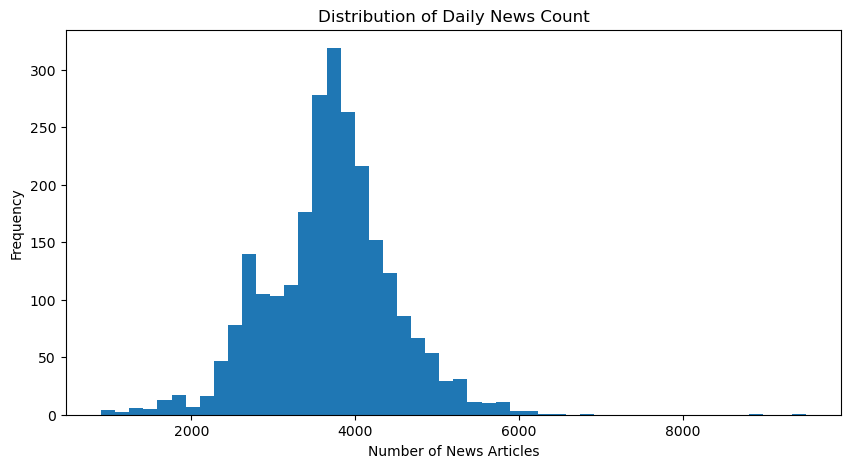

In [38]:
# Plot histogram of the number of daily news articles
plt.figure(figsize=(10,5))
plt.hist(daily_merged["news_count"], bins=50)
plt.title("Distribution of Daily News Count")
plt.xlabel("Number of News Articles")
plt.ylabel("Frequency")
plt.show()

### Daily News Count Over Time

This graph shows how news volume changes across time. The overall level looks fairly stable, but there are several sharp spikes and drops. It helps identify whether news coverage is consistent over the sample period or concentrated around certain periods.

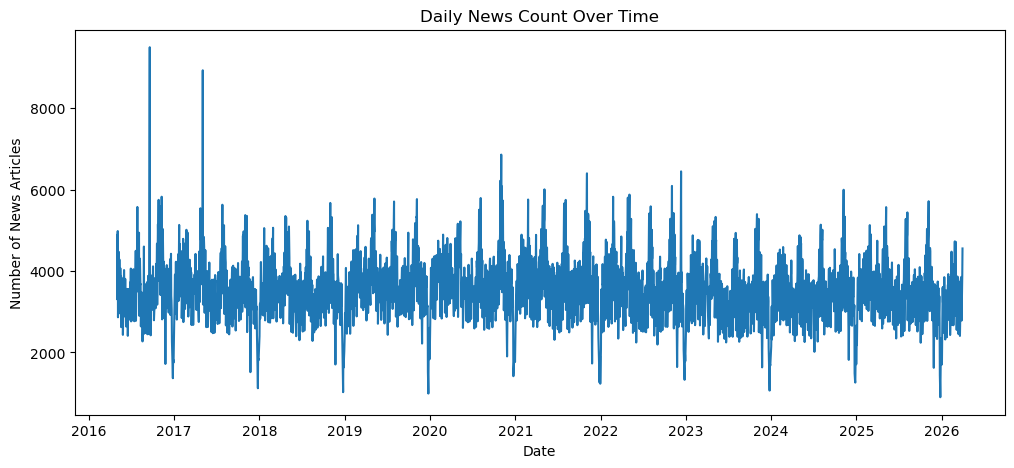

In [39]:
# Time series of news volume
plt.figure(figsize=(12, 5))
plt.plot(daily_merged["trading_date"], daily_merged["news_count"])
plt.title("Daily News Count Over Time")
plt.xlabel("Date")
plt.ylabel("Number of News Articles")
plt.show()


### Daily Sentiment Distribution

The distribution of daily sentiment is unimodal and concentrated, with most observations clustered within a relatively limited range. The values are predominantly positive, as the peak of the distribution lies above zero and a larger portion of observations falls on the positive side. This indicates that average daily sentiment is generally positive, although the interpretation should be based on relative differences rather than absolute values.

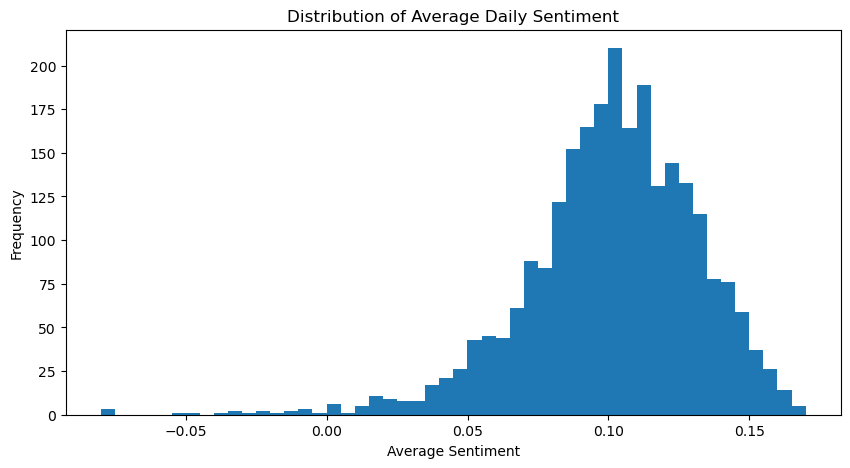

In [40]:
# Aggregate sentiment to the daily level and plot distribution
plt.figure(figsize=(10, 5))
plt.hist(daily_merged["avg_sentiment"], bins=50)
plt.title("Distribution of Average Daily Sentiment")
plt.xlabel("Average Sentiment")
plt.ylabel("Frequency")
plt.show()


### Sentiment Over Time

Average daily sentiment is relatively stable over time but exhibits occasional sharp declines. These drops reflect periods when the overall tone of news becomes more negative. For example, a pronounced decline appears in early 2020, which aligns with the onset of the COVID-19 pandemic, a period of significant global uncertainty and negative news coverage. Similar, fluctuations in other periods suggest that sentiment becomes more volatile during times of market stress.

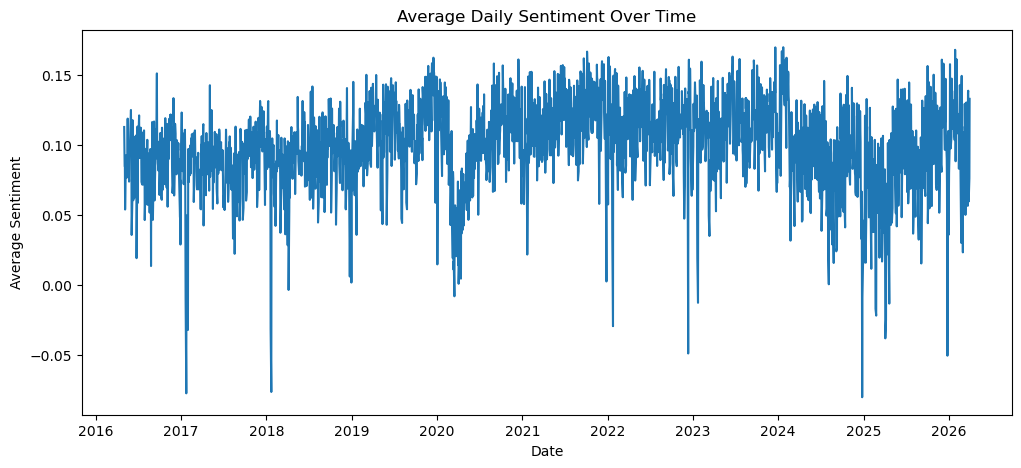

In [41]:
# Time series of the average sentiment (daily)
plt.figure(figsize=(12, 5))
plt.plot(daily_merged["trading_date"], daily_merged["avg_sentiment"])
plt.title("Average Daily Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sentiment")
plt.show()


### LM vs VADER Sentiment Over Time

The LM and VADER sentiment series capture related but different signals. LM is finance-specific, while VADER captures general language tone. Both LM and VADER sentiment measures exhibit similar movements over time, with peaks and declines often occurring at the same periods. This indicates that the two approaches capture comparable changes in news tone.


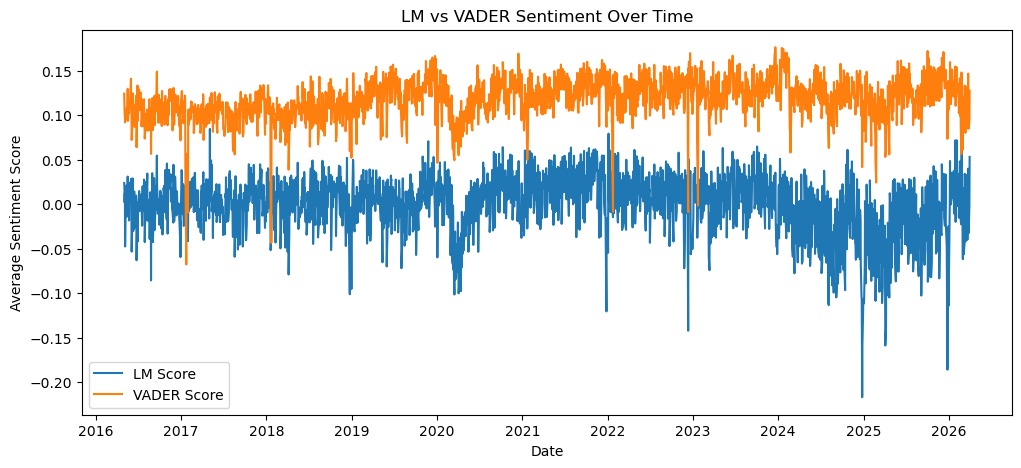

In [42]:
# Time series of the average sentiment score, using different scoring methods
plt.figure(figsize=(12, 5))
plt.plot(daily_merged["trading_date"], daily_merged["avg_lm_score"], label="LM Score")
plt.plot(daily_merged["trading_date"], daily_merged["avg_vader_score"], label="VADER Score")
plt.title("LM vs VADER Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.legend()
plt.show()

### Sentiment Composition Over Time

The composition of news sentiment is relatively stable over time, with neutral news consistently forming the largest share, followed by positive and then negative news. However, the proportion of negative news shows a noticeable increase in the later part of the sample.

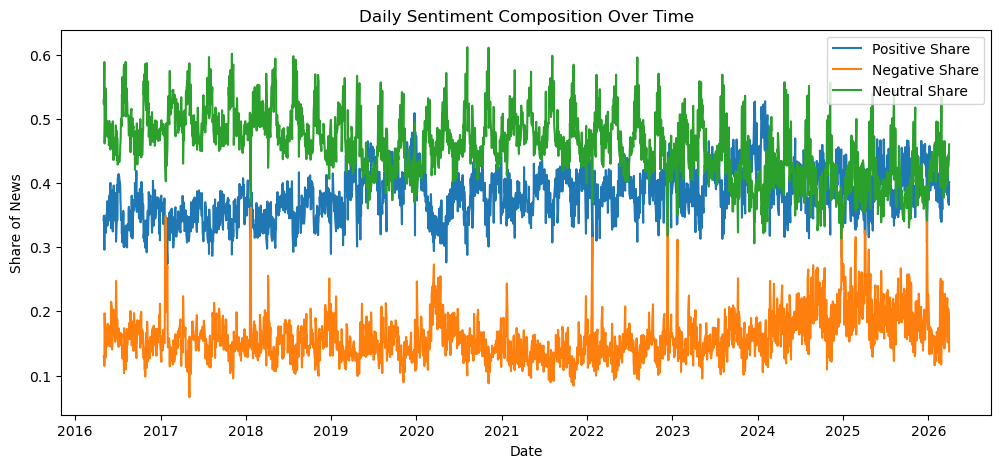

In [43]:
# Time series of news sentiment shares, showing how positive, negative, and neutral proportions evolve over time
plt.figure(figsize=(12, 5))
plt.plot(daily_merged["trading_date"], daily_merged["positive_share"], label="Positive Share")
plt.plot(daily_merged["trading_date"], daily_merged["negative_share"], label="Negative Share")
plt.plot(daily_merged["trading_date"], daily_merged["neutral_share"], label="Neutral Share")
plt.title("Daily Sentiment Composition Over Time")
plt.xlabel("Date")
plt.ylabel("Share of News")
plt.legend()
plt.show()


### Return Distribution

Daily returns are centered around zero, with most observations concentrated near the mean, indicating that typical market movements are small. However, the distribution exhibits noticeable tails on both sides, reflecting the presence of extreme positive and negative returns. The negative tail extends slightly further, suggesting that large downside movements occur more frequently than large upside movements This pattern is consistent with financial return data, where most changes are small but occasional large shocks are present.

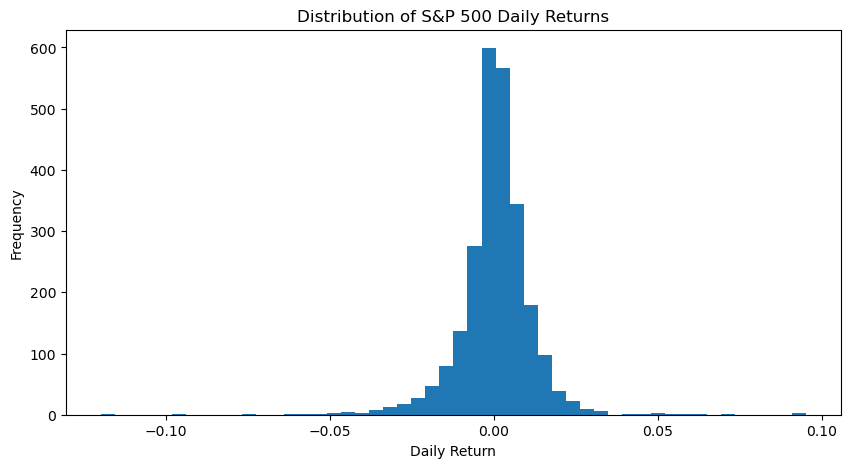

In [44]:
# Histogram of S&P500 daily returns
plt.figure(figsize=(10, 5))
plt.hist(daily_merged["daily_return"], bins=50)
plt.title("Distribution of S&P 500 Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


### S&P 500 Returns Over Time

Daily returns fluctuate around zero with no persistent trend, indicating that market movements are centered and highly variable. Notably, there are sharp spikes around certain periods, such as early 2020, reflecting extreme market movements. This large spikes align with the COVID-19 pandemic, a period of significant global uncertainty. During this time, markets experienced sharp declines followed by strong rebounds, leading to unusually large daily returns.

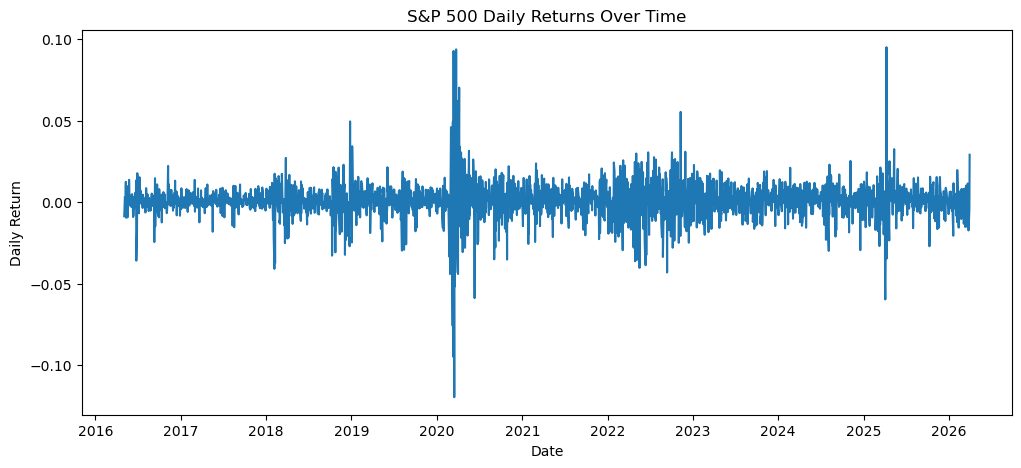

In [45]:
# Time series of daily S&P 500 returns
plt.figure(figsize=(12, 5))
plt.plot(daily_merged["trading_date"], daily_merged["daily_return"])
plt.title("S&P 500 Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

### Sentiment vs Same-Day Return

The scatter plot shows a wide dispersion of points with no clear pattern, indicating a weak relationship between sentiment and same-day returns. Most observations are clustered around zero returns, regardless of sentiment levels.

The correlation is positive but small, suggesting that sentiment has limited explanatory power for market movements within the same day.

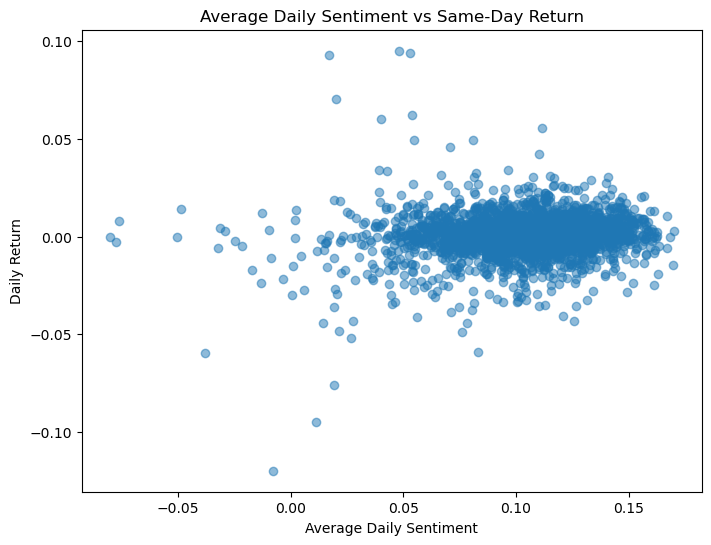

In [46]:
# Scatter plot of average daily sentiment vs same-day returns
plt.figure(figsize=(8, 6))
plt.scatter(daily_merged["avg_sentiment"], daily_merged["daily_return"], alpha=0.5)
plt.title("Average Daily Sentiment vs Same-Day Return")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return")
plt.show()


In [47]:
same_day_corr = daily_merged["avg_sentiment"].corr(daily_merged["daily_return"])
same_day_corr

0.1127831019516983

### Sentiment vs Lag-Day Return

The scatter plot also shows no clear relationship between sentiment and lag-day returns, with observations widely dispersed and most returns clustered around zero.

The correlation is close to zero, indicating that sentiment does not provide meaningful predictive power for lag-day market movements. Compared to same-day returns, the relationship does not improve when introducing a lag.

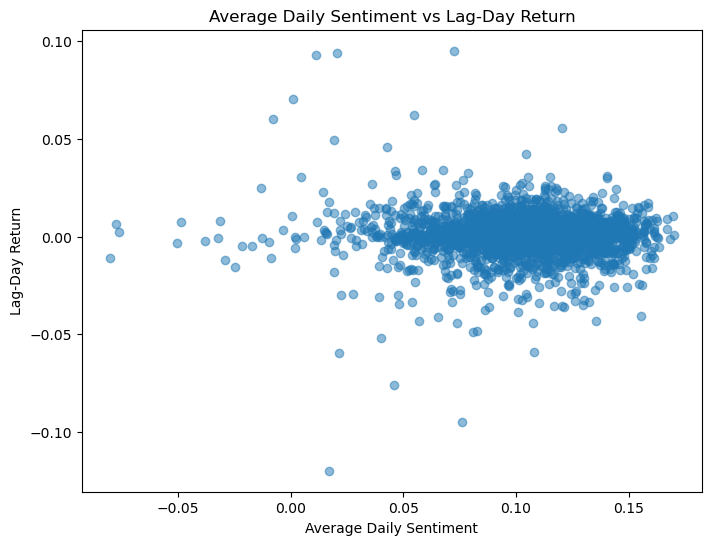

In [48]:
# Scatter plot of average sentiment vs lag-day returns
plt.figure(figsize=(8, 6))
plt.scatter(daily_merged["avg_sentiment"], daily_merged["lag_return"], alpha=0.5)
plt.title("Average Daily Sentiment vs Lag-Day Return")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Lag-Day Return")
plt.show()


In [49]:
# Calculate the correlation of the average sentiment vs lag-day returns
lag_day_corr = daily_merged["avg_sentiment"].corr(daily_merged["lag_return"])
lag_day_corr

-0.03687370921238943

### Correlation Heatmap

The heatmap shows strong positive correlations among sentiment-related variables, indicating that different sentiment measures capture similar information. In particular, LM-based, VADER-based, and share-based sentiment metrics are closely aligned. Negative sentiment share is negatively correlated with overall sentiment, as expected, while neutral share shows weaker relationships with other variables. Importantly, both daily and next-day returns exhibit very weak correlations with all sentiment measures, suggesting that sentiment has limited explanatory or predictive power for market movements. Additionally, returns themselves show little autocorrelation, reflecting the noisy nature of financial markets.

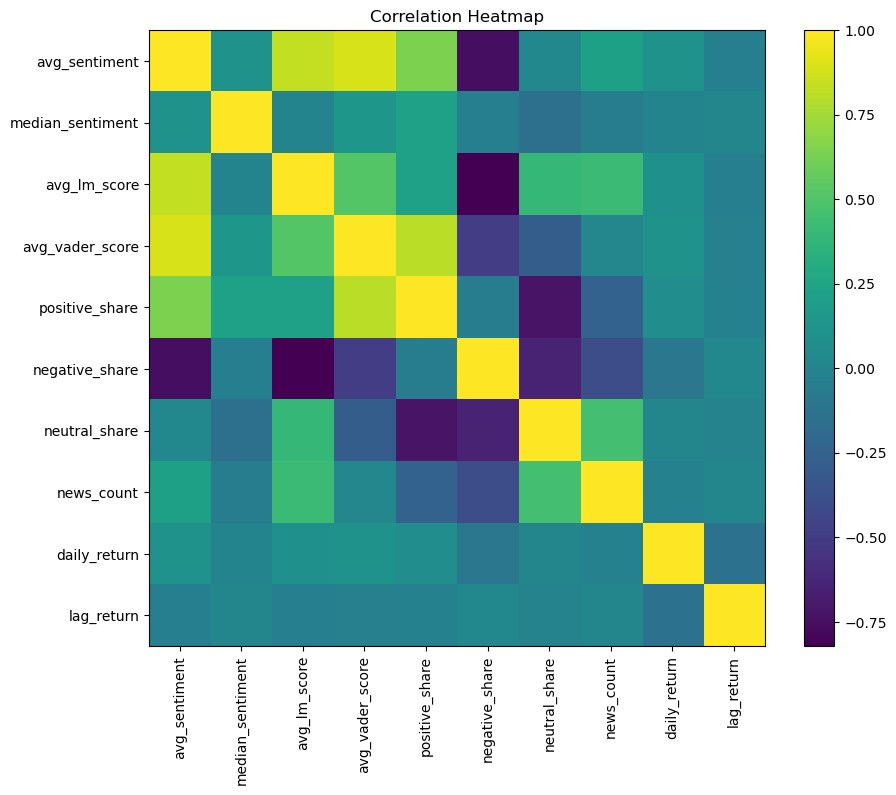

In [50]:
# Compute and visualize correlation matrix (between sentiment, returns, and news volume)
corr_cols = [
    "avg_sentiment",
    "median_sentiment",
    "avg_lm_score",
    "avg_vader_score",
    "positive_share",
    "negative_share",
    "neutral_share",
    "news_count",
    "daily_return",
    "lag_return"
]

corr_matrix = daily_merged[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap")
plt.show()


In [51]:
# Numerical values of the correlation matrix
corr_matrix

,avg_sentiment,median_sentiment,avg_lm_score,avg_vader_score,positive_share,negative_share,neutral_share,news_count,daily_return,lag_return
avg_sentiment,1.000000,0.103804,0.832243,0.892143,0.640617,-0.757783,0.027927,0.216155,0.112783,-0.036874
median_sentiment,0.103804,1.000000,-0.003106,0.144432,0.219136,-0.032794,-0.145970,-0.052173,0.003080,0.011699
avg_lm_score,0.832243,-0.003106,1.000000,0.512003,0.223408,-0.821865,0.392740,0.417556,0.094827,-0.037395
avg_vader_score,0.892143,0.144432,0.512003,1.000000,0.810809,-0.491254,-0.286009,0.018987,0.110476,-0.028727
positive_share,0.640617,0.219136,0.223408,0.810809,1.000000,-0.059664,-0.727928,-0.250401,0.070047,-0.019495
negative_share,-0.757783,-0.032794,-0.821865,-0.491254,-0.059664,1.000000,-0.641001,-0.387942,-0.101600,0.028122
neutral_share,0.027927,-0.145970,0.392740,-0.286009,-0.727928,-0.641001,1.000000,0.459004,0.015935,-0.004327
news_count,0.216155,-0.052173,0.417556,0.018987,-0.250401,-0.387942,0.459004,1.000000,-0.018262,0.015785
daily_return,0.112783,0.003080,0.094827,0.110476,0.070047,-0.101600,0.015935,-0.018262,1.000000,-0.144238
lag_return,-0.036874,0.011699,-0.037395,-0.028727,-0.019495,0.028122,-0.004327,0.015785,-0.144238,1.000000


### Sentiment and Returns Over Time (Scaled)

Both sentiment and returns are standardized to allow direct comparison. The plot shows that returns exhibit much larger and more frequent spikes, while sentiment remains relatively smooth and stable. There is no consistent alignment between the two series, as large movements in returns do not correspond to equally strong changes in sentiment. This suggests that sentiment does not closely track market fluctuations over time.

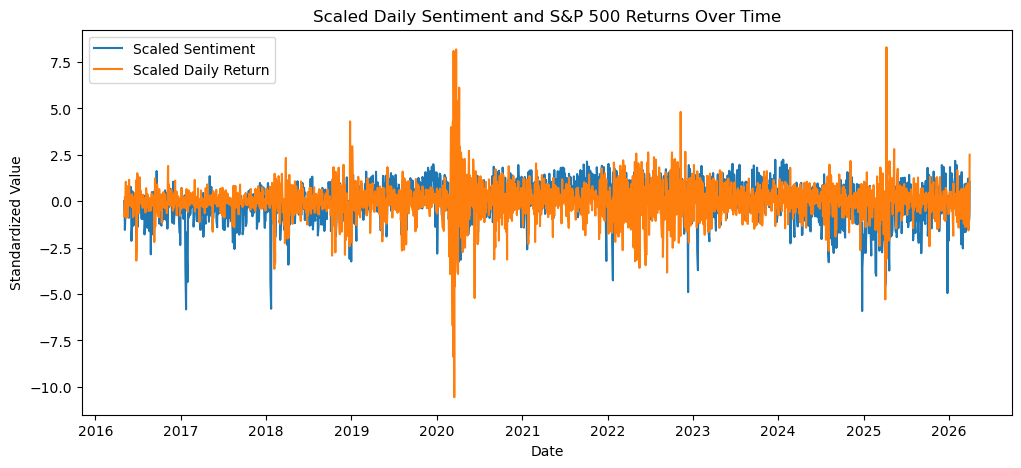

In [52]:
# Calculate the standardized sentiment scores and returns
overlay_df = daily_merged[["trading_date", "avg_sentiment", "daily_return"]].dropna().copy()

overlay_df["avg_sentiment_scaled"] = (
    overlay_df["avg_sentiment"] - overlay_df["avg_sentiment"].mean()
) / overlay_df["avg_sentiment"].std()

overlay_df["daily_return_scaled"] = (
    overlay_df["daily_return"] - overlay_df["daily_return"].mean()
) / overlay_df["daily_return"].std()

# Time series of standardized sentiment and returns
plt.figure(figsize=(12, 5))
plt.plot(overlay_df["trading_date"], overlay_df["avg_sentiment_scaled"], label="Scaled Sentiment")
plt.plot(overlay_df["trading_date"], overlay_df["daily_return_scaled"], label="Scaled Daily Return")
plt.title("Scaled Daily Sentiment and S&P 500 Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend()
plt.show()


### Returns by Sentiment Group

We group trading days into negative, neutral, and positive sentiment categories and compare their average same-day and lag-day returns. The differences in returns across groups do not follow a consistent pattern. For example, neutral sentiment shows the lowest same-day return but the highest lag-day return, while negative and positive groups display similar values in some cases. This indicates that grouping sentiment does not reveal a clear or stable relationship with market returns.

/var/folders/jb/_57y0k0x0wj5rxjpxc000yxc0000gn/T/ipykernel_33177/3174449564.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_return = daily_merged.groupby("sentiment_group")[["daily_return", "lag_return"]].mean()


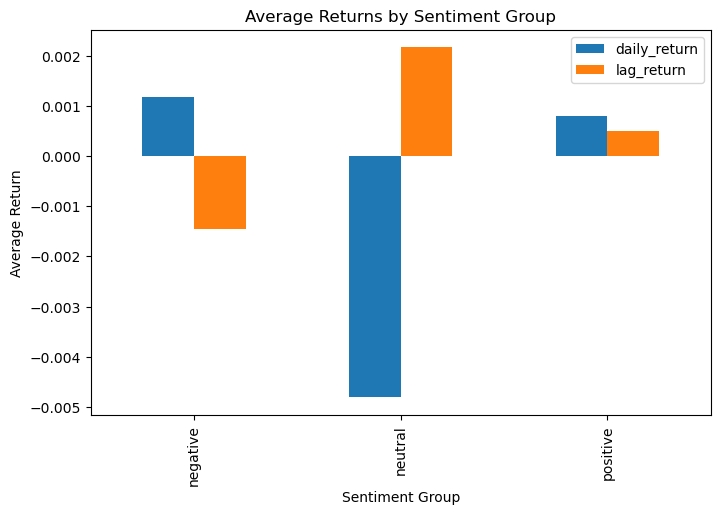

In [ ]:
# Categorize daily sentiment into negative, neutral, and positive groups using a predefined threshold
daily_merged["sentiment_group"] = pd.cut(
    daily_merged["avg_sentiment"],
    bins=[-np.inf, -threshold, threshold, np.inf],
    labels=["negative", "neutral", "positive"]
)

# Group days into sentiment categories and compare returns
group_return = daily_merged.groupby("sentiment_group")[["daily_return", "lag_return"]].mean()

group_return.plot(kind="bar", figsize=(8, 5))
plt.title("Average Returns by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Return")
plt.show()


### News Volume Group Analysis

We group days based on the number of news articles into low, medium, and high news volume categories, and compare their average same-day and lag-day returns. The results show that same-day returns are highest for low and medium news volume days, while high news volume days have noticeably lower same-day returns. In contrast, lag-day returns are highest for high news volume days, exceeding those of low and medium volume groups. This suggests that while markets may react negatively or weakly on days with heavy news flow, there may be a delayed adjustment, with stronger returns occurring the following day.

/var/folders/jb/_57y0k0x0wj5rxjpxc000yxc0000gn/T/ipykernel_33177/211506890.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_return = daily_merged.groupby("news_volume_group")[["daily_return", "lag_return"]].mean()


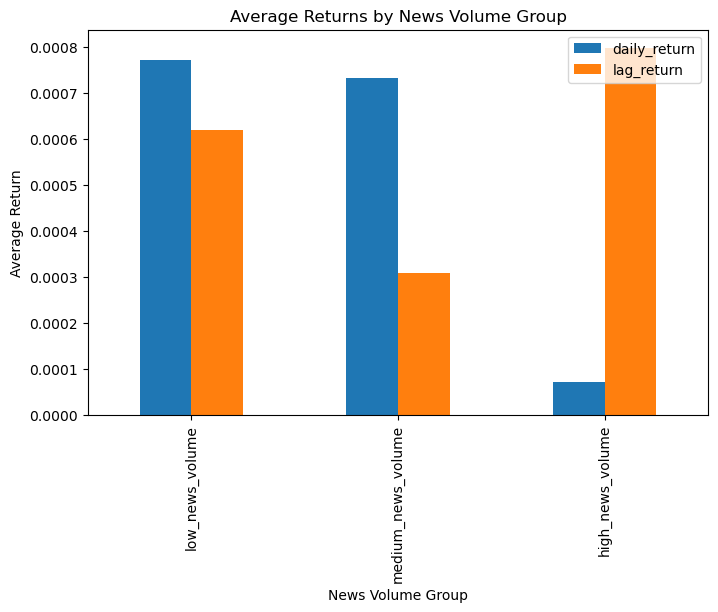

In [56]:
# Split days into low, medium, and high news volume groups using quantiles
daily_merged["news_volume_group"] = pd.qcut(
    daily_merged["news_count"],
    q=3,
    labels=["low_news_volume", "medium_news_volume", "high_news_volume"]
)

# Group days by news volume (low/medium/high) and compare returns
volume_return = daily_merged.groupby("news_volume_group")[["daily_return", "lag_return"]].mean()

volume_return.plot(kind="bar", figsize=(8, 5))
plt.title("Average Returns by News Volume Group")
plt.xlabel("News Volume Group")
plt.ylabel("Average Return")
plt.show()


### Interaction: Sentiment and News Volume

To better understand whether the effect of sentiment depends on the level of market attention, we introduce an interaction between sentiment and news volume. First, we classify each day into low or high news volume based on whether the number of news articles is below or above the median. Next, we analyze returns across both sentiment groups (negative, neutral, positive) and news volume conditions (low vs high). 

The results suggest that the relationship between sentiment and returns is not uniform across news environments. In some cases, the same sentiment category produces different return patterns depending on whether news volume is high or low. For example, in the results, negative sentiment behaves differently depending on news volume: on low news days, returns are slightly negative, while on high news days, returns become positive. This suggests that the same “negative sentiment” can lead to different market outcomes depending on how much news is released. In contrast, positive sentiment shows only small differences between low and high news volume, indicating a relatively stable effect. Neutral sentiment also varies across volume levels, but without a clear or consistent pattern. These results suggest that sentiment alone does not fully explain market behavior, as the level of news activity can influence how sentiment is reflected in returns.

In [57]:
# Create high vs low news volume indicator based on median split
daily_merged["high_news_volume"] = (
    daily_merged["news_count"] >= daily_merged["news_count"].median()
).astype(int)

# Create interaction term between sentiment and news volume
daily_merged["sentiment_x_news_volume"] = (
    daily_merged["avg_sentiment"] * daily_merged["high_news_volume"]
)

daily_merged[[
    "avg_sentiment",
    "news_count",
    "high_news_volume",
    "sentiment_x_news_volume",
    "daily_return",
    "lag_return"
]].head()


,avg_sentiment,news_count,high_news_volume,sentiment_x_news_volume,daily_return,lag_return
0,0.113014,3312,0,0.000000,NaN,-0.008677
1,0.101657,4879,1,0.101657,-0.008677,-0.005937
2,0.085079,4877,1,0.085079,-0.005937,-0.000239
3,0.085063,4984,1,0.085063,-0.000239,0.003175
4,0.054049,2864,0,0.000000,0.003175,0.000753


In [58]:
# Group by sentiment and news volume to compare returns
interaction_summary = daily_merged.groupby(
    ["sentiment_group", "high_news_volume"]
)[["daily_return", "lag_return"]].mean()

interaction_summary

/var/folders/jb/_57y0k0x0wj5rxjpxc000yxc0000gn/T/ipykernel_33177/772535143.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction_summary = daily_merged.groupby(


daily_return  lag_return
sentiment_group high_news_volume                          
negative        0                    -0.000355   -0.007274
                1                     0.002688    0.004369
neutral         0                    -0.004445    0.001330
                1                    -0.005436    0.003618
positive        0                     0.001002    0.000486
                1                     0.000619    0.000499

## Conclusion

The results show that there is no strong or consistent relationship between news sentiment and S&P 500 returns. Based on different methods like correlation, scatter plots, and group comparisons, sentiment only has a very weak connection with both same-day and next-day returns. The patterns are unclear, and the correlation values are close to zero, which means sentiment does not reliably explain market movements.

When we group sentiment into negative, neutral, and positive categories, we do see small differences in returns, but these differences are not large and not consistent over time. This suggests that sentiment alone is not a reliable factor for predicting market behavior.

The interaction analysis with news volume provides some additional detail. The relationship between sentiment and returns seems to change slightly depending on how much news there is. However, these differences are still not strong enough to show a clear or reliable pattern.

Overall, the results suggest that while news sentiment may contain some useful information, it is not enough by itself to explain or predict stock market returns. This shows that financial markets are complex and influenced by many other factors beyond just news sentiment.

In the future, this analysis could be improved by using more detailed data, better sentiment models, or focusing on specific companies instead of the overall market. These changes might help find stronger relationships between news and market movements.